In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns   

### EDA

In [2]:
df = pd.read_csv('Telco Customer Churn.csv')

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
# ما نسبة الـ Churn داخل كل فئة
categorical_cols = df.select_dtypes(include=['object']).columns.drop(['Churn', 'customerID'])
for col in categorical_cols:
    print(f"Churn distribution for column '{col}':")
    print(df.groupby(col)['Churn'].value_counts(normalize=True))
    print("\n")

Churn distribution for column 'gender':
gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64


Churn distribution for column 'Partner':
Partner  Churn
No       No       0.670420
         Yes      0.329580
Yes      No       0.803351
         Yes      0.196649
Name: proportion, dtype: float64


Churn distribution for column 'Dependents':
Dependents  Churn
No          No       0.687209
            Yes      0.312791
Yes         No       0.845498
            Yes      0.154502
Name: proportion, dtype: float64


Churn distribution for column 'PhoneService':
PhoneService  Churn
No            No       0.750733
              Yes      0.249267
Yes           No       0.732904
              Yes      0.267096
Name: proportion, dtype: float64


Churn distribution for column 'MultipleLines':
MultipleLines     Churn
No                No       0.749558
                  Yes      0.250442
No phone service  N

C:\Users\ahmed\AppData\Local\Temp\ipykernel_1916\3637087074.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop(['Churn', 'customerID'])


In [8]:
# change TotalCharges datatype to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# fill missing values with the corresponding MonthlyCharges value
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Feature: عدد الخدمات الإضافية المشترك فيها العميل
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Num_services'] = df[service_cols].apply(lambda row: row.eq('Yes').sum(), axis=1)

In [9]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [10]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Feature Engineering 

In [11]:
df.drop(columns=['customerID'], inplace=True)

In [12]:
df['Billing_average'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [13]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies']

no_values = ['No', 'No internet service', 'No phone service']

df['TotalServices'] = (~df[service_cols].isin(no_values)).sum(axis=1)

In [14]:
label_encoder = LabelEncoder()

Label_group = df[['Contract']]
for col in Label_group.columns:
    df[col] = label_encoder.fit_transform(df[col])


onehot_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaymentMethod',
               'PaperlessBilling']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

In [15]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

### Model

In [31]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier


In [32]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Baseline model comparison using the same train/test split
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, max_depth=5, n_estimators=100,
                             scale_pos_weight=imbalance_ratio, eval_metric='logloss')
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_Churn': precision_score(y_test, y_pred),
        'Recall_Churn': recall_score(y_test, y_pred),
        'F1_Churn': f1_score(y_test, y_pred)
    })

model_results = pd.DataFrame(results).sort_values('Recall_Churn', ascending=False)
display(model_results)


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, scale_pos_weight=imbalance_ratio, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid.fit(X_train, y_train)


In [ ]:
print(grid.best_params_)
print(grid.best_score_)

In [ ]:
best_boost_model = grid.best_estimator_
y_pred_best_xgb = best_boost_model.predict(X_test)

print(classification_report(y_test, y_pred_best_xgb))
print(confusion_matrix(y_test, y_pred_best_xgb))

In [48]:
import shap

explainer = shap.TreeExplainer(best_boost_model)
shap_values = explainer(X_test)

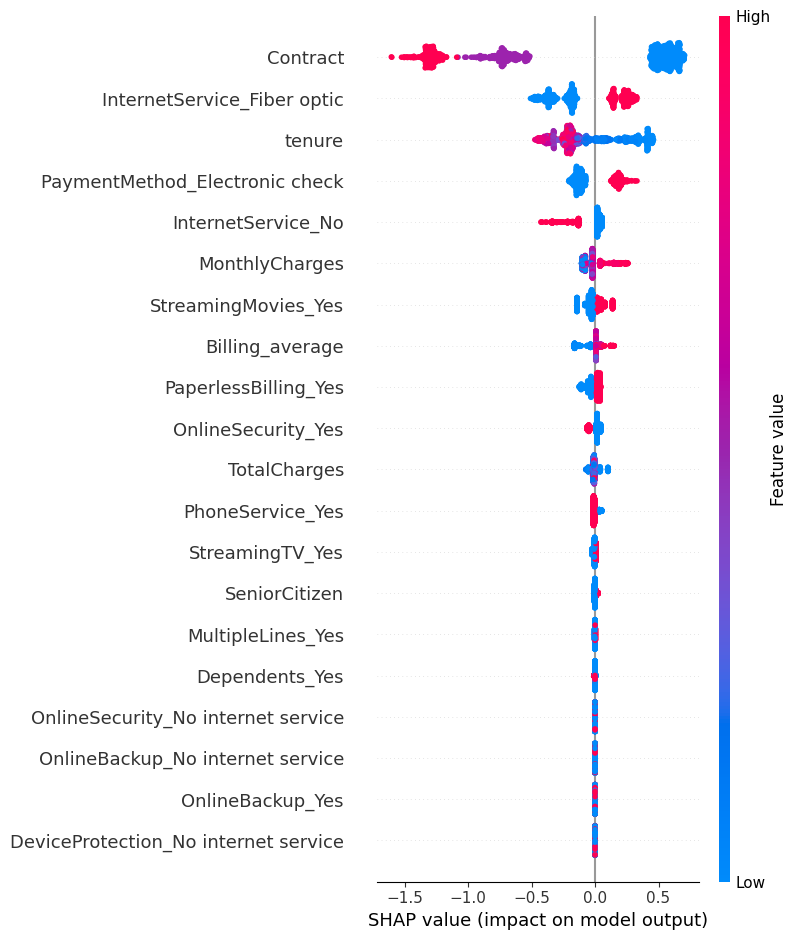

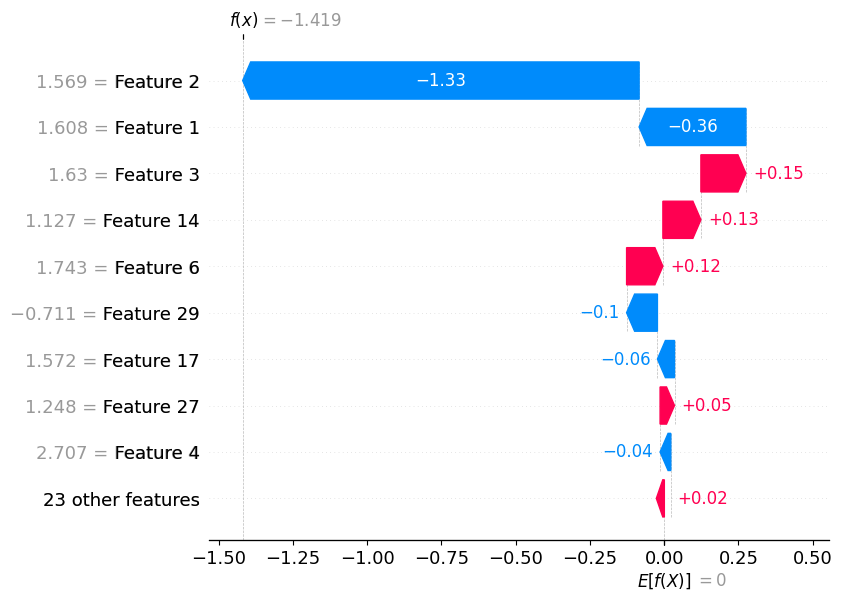

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.show()
shap.waterfall_plot(shap_values[0])
plt.show()

### Streamlit Dashboard

In [57]:
import joblib
joblib.dump(best_boost_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [58]:

cols = joblib.load('feature_columns.pkl')
# اطبع الأعمدة المتعلقة بـ InternetService وPaymentMethod
print([c for c in cols if 'Internet' in c or 'Payment' in c])

['InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
